In [55]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import os
os.environ["TF_USE_DIRECTML"] = "1"

print("DirectML Devices:", tf.config.list_physical_devices('GPU'))  # Should show your GPU

DirectML Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [56]:
def extract_patches(image, patch_size=32, stride=16):
    """Extract overlapping patches from an image"""
    patches = tf.image.extract_patches(
        images=tf.expand_dims(image, 0), # artificially increase the dimensions to (1, w, h, c), necessary for extract function
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1], # rates is used for dilatation 
        padding='VALID' # Only use fully contained patches
    )
    return tf.reshape(patches, [-1, patch_size, patch_size, image.shape[-1]]) # reshape patches to (num_patches, w, h, c)

# Example usage:
# n = 224
# images = np.array([[[x * n + y + 1] for y in range(n)] for x in range(n)]) 
# print(extract_patches(images, 64, 16).shape) # outputs 169,32,32,1

In [57]:
class PatchBagGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_arrays, labels, patch_size=32, stride=16, batch_size=32):
        """
        Args:
            image_arrays: Array of preloaded images (h,w,c)
            labels: Corresponding labels
            patch_size: Size of square patches
            stride: Step between patches
            batch_size: Number of images per batch
        """
        self.image_arrays = image_arrays
        self.labels = labels
        self.patch_size = patch_size
        self.stride = stride
        self.batch_size = batch_size
        self.num_samples = len(image_arrays)
        self.indices = np.arange(self.num_samples)
        assert self.image_arrays.shape == (self.num_samples, 224, 224, 1), "Image arrays shape mismatch: {} vs {}".format(image_arrays.shape, (self.num_samples, 224, 224, 1))
                
    def __len__(self):
        return int(np.ceil(self.num_samples / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size] # retrieve indices for current batch index
        batch_images = [self.image_arrays[i] for i in batch_indices] # retrieve images for current batch
        batch_labels = [self.labels[i] for i in batch_indices] # retrieve labels for current batch
        
        # Process each image into patches
        batch_bags = []
        for img in batch_images:
            batch_bags.append(extract_patches(img, patch_size=self.patch_size, stride=self.stride)) 
                
        return np.array(batch_bags), np.array(batch_labels)
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices) # randomize batches for next epoch

In [58]:
def additional_augment(image, label, prob=0.3):
    
    image = tf.cast(image, tf.float32)
    
    if tf.shape(image)[-1] == 3:
        image = tf.image.rgb_to_grayscale(image)
        
    image = image / 255.0
    
    
    def augment():

        # Random horizontal flip with 50% chance
        aug_image = tf.image.random_flip_left_right(image)

        # Random brightness adjustment
        aug_image = tf.image.random_brightness(aug_image, max_delta=0.05)

        # Random contrast adjustment
        aug_image = tf.image.random_contrast(aug_image, lower=0.95, upper=1.05)

        # Add Gaussian noise
        noise = tf.random.normal(shape=tf.shape(aug_image), mean=0.0, stddev=0.05)
        aug_image = aug_image + noise

        aug_image = tf.clip_by_value(aug_image, 0.0, 1.0)

        return aug_image
    
    do_augment = tf.less(tf.random.uniform([], 0, 1.0), prob)
    image_aug = tf.cond(do_augment, augment, lambda: image)
    
    return image_aug, label

In [59]:
def extract_generator_data(generator):
    """Convert generator output to arrays"""
    images, labels = [], []
    generator.reset() # ensure to retrieve all data from generator start
    for i in range(len(generator)):
        batch_img, batch_lbl = generator[i]
        images.append(batch_img)
        labels.append(batch_lbl)
    return np.vstack(images), np.vstack(labels)

# initialize generator for data retrieval
train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_path = "C:\\Users\\Borajin\\.cache\\data\\preprocessed\\Training"

# create training and validation generators from data
train_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    color_mode="grayscale"
)

val_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    color_mode="grayscale"
)

# convert generators to Data array containing images and label vector containing classes
X_train, y_train = extract_generator_data(train_dir_gen)
X_val, y_val = extract_generator_data(val_dir_gen)

print("Class indices:", train_dir_gen.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [50]:
def create_basic_mil_model(patch_size=32, num_classes=4):
    """Create MIL model using max/mean pooling"""
    
    # Instance-level model (processes individual patches)
    instance_input = layers.Input(shape=(patch_size, patch_size, 1))
    x = layers.Concatenate(axis=-1)([instance_input]*3)
    
    # Feature extractor
    vgg = VGG16(weights='imagenet', include_top=False, input_shape=(patch_size, patch_size, 3), pooling='avg')
    vgg.trainable = False # TODO look up what this does
    
    x = vgg(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    instance_output = layers.LayerNormalization()(x)
    
    instance_model = Model(instance_input, instance_output)
    # TODO "saliency"
    
    # Bag-level model applying the instance level model to each of the patches (using TimeDistributed)
    bag_input = layers.Input(shape=(None, patch_size, patch_size, 1))
    x = layers.TimeDistributed(instance_model)(bag_input)
  
    bag_representation = layers.GlobalMaxPooling1D()(x)
    # bag_representation = layers.Dropout(0.5)(x)
    
    # Classification head
    output = layers.Dense(num_classes, activation='softmax')(bag_representation)
    
    return Model(bag_input, output)

In [53]:
# Create and compile model
model = create_basic_mil_model(patch_size=64, num_classes=4)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create data generators 
train_mil_gen = PatchBagGenerator(
    image_arrays=X_train,
    labels=y_train,
    patch_size=64,
    stride=16,
    batch_size=16
)

val_mil_gen = PatchBagGenerator(
    image_arrays=X_val,
    labels=y_val,
    patch_size=64,
    stride=16,
    batch_size=16
)

# Train
history = model.fit(
    train_mil_gen,
    validation_data=val_mil_gen,
    epochs=10
)

Epoch 1/10
144/144 [==============================] - 32s 220ms/step - loss: 2.5257 - accuracy: 0.7114 - val_loss: 2.1066 - val_accuracy: 0.6719
Epoch 2/10
144/144 [==============================] - 32s 221ms/step - loss: 1.3108 - accuracy: 0.8912 - val_loss: 1.4536 - val_accuracy: 0.7644
Epoch 3/10
144/144 [==============================] - 33s 228ms/step - loss: 0.9004 - accuracy: 0.9338 - val_loss: 1.2120 - val_accuracy: 0.7661
Epoch 4/10
144/144 [==============================] - 32s 220ms/step - loss: 0.6579 - accuracy: 0.9547 - val_loss: 1.0198 - val_accuracy: 0.7993
Epoch 5/10
144/144 [==============================] - 32s 220ms/step - loss: 0.5307 - accuracy: 0.9630 - val_loss: 1.0085 - val_accuracy: 0.7906
Epoch 6/10
144/144 [==============================] - 32s 221ms/step - loss: 0.4237 - accuracy: 0.9778 - val_loss: 0.8427 - val_accuracy: 0.8360
Epoch 7/10
144/144 [==============================] - 32s 220ms/step - loss: 0.3893 - accuracy: 0.9717 - val_loss: 0.9692 - val_ac

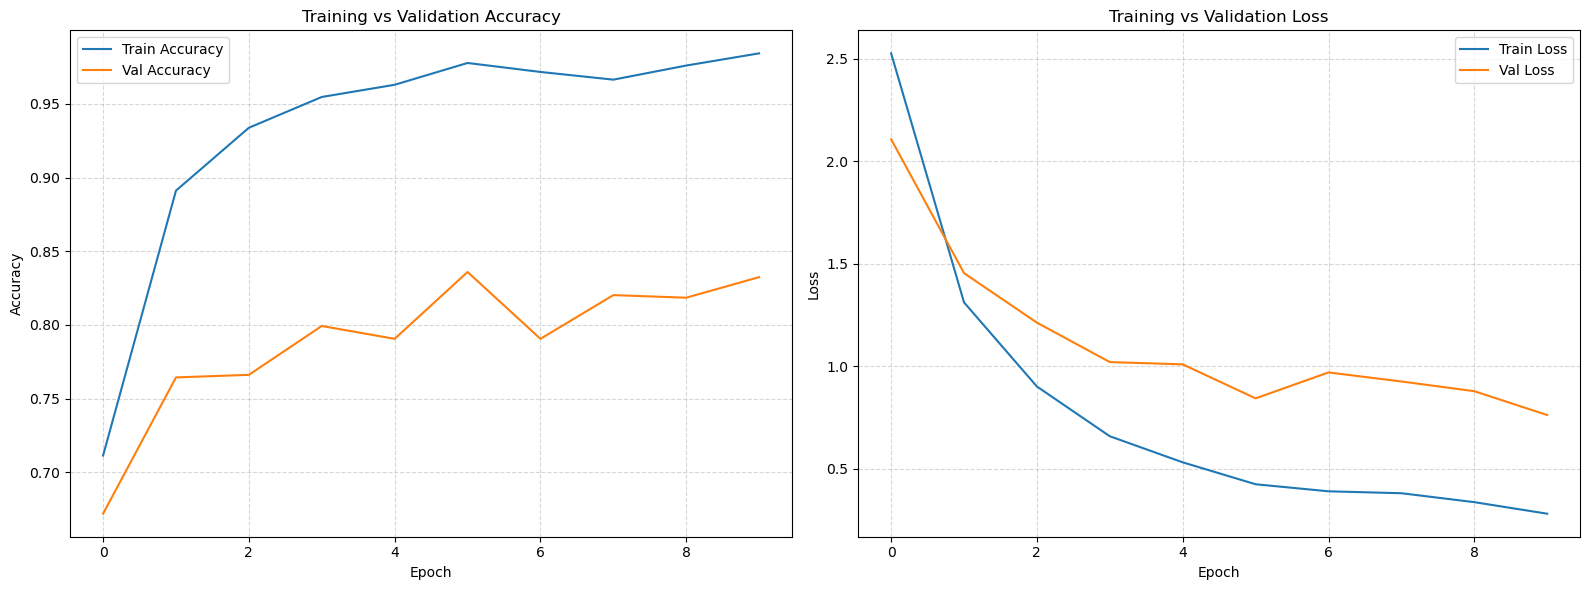

In [70]:
import matplotlib
import matplotlib.pyplot as plt

# Set global font sizes when used for presentation
# plt.rcParams.update({
#     'axes.titlesize': 18,    # Title font size
#     'axes.labelsize': 16,    # X and Y axis label size
#     'xtick.labelsize': 14,   # X-axis tick label size
#     'ytick.labelsize': 14,   # Y-axis tick label size
#     'legend.fontsize': 14,   # Legend font size
# })
plt.rcParams.update(matplotlib.rcParamsDefault) # else restore default parameters

# Create figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Accuracy ---
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Loss ---
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training vs Validation Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# Improve layout and save
plt.tight_layout()
plt.savefig('test/accuracy_and_loss.jpg', dpi=300, bbox_inches='tight')
plt.show()


# TODO implement confusion matrix